<a href="https://colab.research.google.com/github/diviraj14/my-aiml-learning/blob/main/clustering%20%26%20pca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (1067371, 8)
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

          InvoiceDate  Price  Customer ID         Country  
0 2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2 2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3 2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4 2009-12-01 07:45:00   1.25      13085.0  United Kingdom  

After Cleaning: (805549, 9)

RFM DATA:
   Customer ID  Recency  Frequency  Monetary
0      12346.0      326         12  77556.46
1      12347.0        2          8   5633.32
2      12348.0  

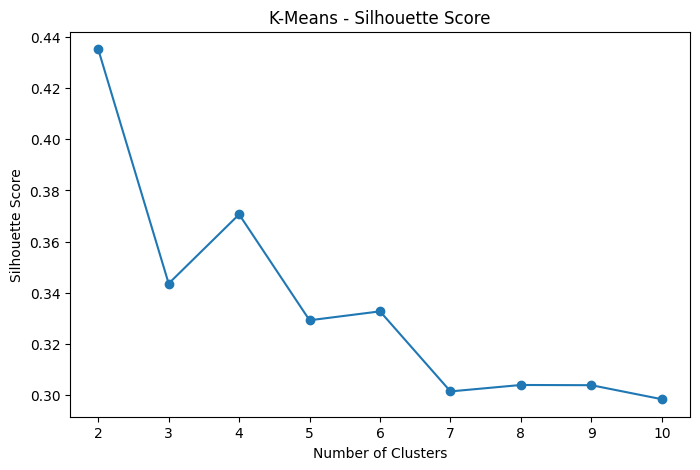


================ HIERARCHICAL ================


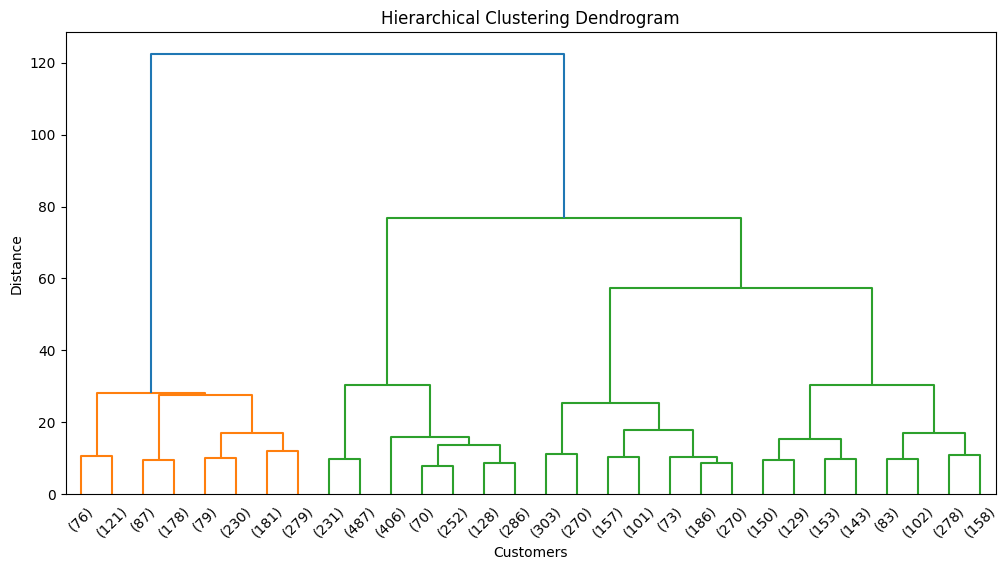

Hierarchical Silhouette Score: 0.4172

================ DBSCAN ================
Number of DBSCAN Clusters: 2
Number of Noise Points: 24
DBSCAN Silhouette Score: 0.2786

CLUSTERING ALGORITHM COMPARISON
K-Means Silhouette Score      : 0.4352
Hierarchical Silhouette Score : 0.4172
DBSCAN Silhouette Score       : 0.2786

K-Means Cluster Counts:
KMeans_Cluster
0    3281
1    2366
Name: count, dtype: int64

Hierarchical Cluster Counts:
Hierarchical_Cluster
0    4416
1    1231
Name: count, dtype: int64

DBSCAN Cluster Counts:
DBSCAN_Cluster
-1      24
 0    4114
 1    1509
Name: count, dtype: int64

Results saved as:
customer_clustering_results.csv


In [1]:
# ============================================================
# CUSTOMER SEGMENTATION USING
# 1. K-MEANS
# 2. HIERARCHICAL CLUSTERING
# 3. DBSCAN
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ------------------------------------------------------------
# STEP 1: LOAD DATA
# ------------------------------------------------------------

file_path = "online_retail_II.xlsx"

df1 = pd.read_excel(file_path, sheet_name="Year 2009-2010")
df2 = pd.read_excel(file_path, sheet_name="Year 2010-2011")

# Combine both years
df = pd.concat([df1, df2], ignore_index=True)

print("Dataset Shape:", df.shape)
print(df.head())

# ------------------------------------------------------------
# STEP 2: DATA CLEANING
# ------------------------------------------------------------

# Remove rows without Customer ID
df = df.dropna(subset=["Customer ID"])

# Remove cancelled invoices
df = df[~df["Invoice"].astype(str).str.startswith("C")]

# Remove invalid quantity and price
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Create Total Amount
df["TotalAmount"] = df["Quantity"] * df["Price"]

print("\nAfter Cleaning:", df.shape)

# ------------------------------------------------------------
# STEP 3: CREATE RFM FEATURES
# R = Recency
# F = Frequency
# M = Monetary
# ------------------------------------------------------------

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer ID").agg(
    Recency=("InvoiceDate",
             lambda x: (reference_date - x.max()).days),

    Frequency=("Invoice",
               "nunique"),

    Monetary=("TotalAmount",
              "sum")
).reset_index()

print("\nRFM DATA:")
print(rfm.head())

# ------------------------------------------------------------
# STEP 4: REMOVE EXTREME OUTLIERS
# ------------------------------------------------------------

for column in ["Recency", "Frequency", "Monetary"]:
    Q1 = rfm[column].quantile(0.01)
    Q99 = rfm[column].quantile(0.99)

    rfm = rfm[
        (rfm[column] >= Q1) &
        (rfm[column] <= Q99)
    ]

print("\nRFM Shape:", rfm.shape)

# ------------------------------------------------------------
# STEP 5: LOG TRANSFORMATION
# ------------------------------------------------------------

rfm_features = rfm[["Recency", "Frequency", "Monetary"]].copy()

rfm_features["Recency"] = np.log1p(rfm_features["Recency"])
rfm_features["Frequency"] = np.log1p(rfm_features["Frequency"])
rfm_features["Monetary"] = np.log1p(rfm_features["Monetary"])

# ------------------------------------------------------------
# STEP 6: STANDARDIZATION
# ------------------------------------------------------------

scaler = StandardScaler()

X = scaler.fit_transform(rfm_features)

print("\nScaled Data Shape:", X.shape)

# ============================================================
# 1. K-MEANS CLUSTERING
# ============================================================

print("\n================ K-MEANS ================")

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X)

    score = silhouette_score(X, labels)

    silhouette_scores.append(score)

    print("K =", k, "Silhouette Score =", round(score, 4))

# Find best K
best_k = range(2, 11)[np.argmax(silhouette_scores)]

print("\nBest K =", best_k)

# Final K-Means model
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

rfm["KMeans_Cluster"] = kmeans.fit_predict(X)

kmeans_score = silhouette_score(
    X,
    rfm["KMeans_Cluster"]
)

print("K-Means Silhouette Score:",
      round(kmeans_score, 4))

# Plot K-Means scores
plt.figure(figsize=(8, 5))
plt.plot(
    range(2, 11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means - Silhouette Score")
plt.show()

# ============================================================
# 2. HIERARCHICAL CLUSTERING
# ============================================================

print("\n================ HIERARCHICAL ================")

# Dendrogram
plt.figure(figsize=(12, 6))

linkage_matrix = linkage(
    X,
    method="ward"
)

dendrogram(
    linkage_matrix,
    truncate_mode="lastp",
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

# Use same best number of clusters
hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

rfm["Hierarchical_Cluster"] = hierarchical.fit_predict(X)

hierarchical_score = silhouette_score(
    X,
    rfm["Hierarchical_Cluster"]
)

print("Hierarchical Silhouette Score:",
      round(hierarchical_score, 4))

# ============================================================
# 3. DBSCAN
# ============================================================

print("\n================ DBSCAN ================")

# DBSCAN parameters
dbscan = DBSCAN(
    eps=0.5,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X)

rfm["DBSCAN_Cluster"] = dbscan_labels

# Number of clusters excluding noise (-1)
unique_clusters = set(dbscan_labels)
n_clusters = len(unique_clusters - {-1})

n_noise = list(dbscan_labels).count(-1)

print("Number of DBSCAN Clusters:", n_clusters)
print("Number of Noise Points:", n_noise)

# Silhouette score only when there are at least 2 clusters
non_noise = dbscan_labels != -1

if n_clusters >= 2 and sum(non_noise) > 1:

    dbscan_score = silhouette_score(
        X[non_noise],
        dbscan_labels[non_noise]
    )

    print("DBSCAN Silhouette Score:",
          round(dbscan_score, 4))

else:

    dbscan_score = None

    print("Silhouette Score cannot be calculated.")

# ============================================================
# COMPARISON
# ============================================================

print("\n==============================================")
print("CLUSTERING ALGORITHM COMPARISON")
print("==============================================")

print(
    "K-Means Silhouette Score      :",
    round(kmeans_score, 4)
)

print(
    "Hierarchical Silhouette Score :",
    round(hierarchical_score, 4)
)

if dbscan_score is not None:
    print(
        "DBSCAN Silhouette Score       :",
        round(dbscan_score, 4)
    )

# ============================================================
# CLUSTER COUNTS
# ============================================================

print("\nK-Means Cluster Counts:")
print(rfm["KMeans_Cluster"].value_counts().sort_index())

print("\nHierarchical Cluster Counts:")
print(rfm["Hierarchical_Cluster"].value_counts().sort_index())

print("\nDBSCAN Cluster Counts:")
print(rfm["DBSCAN_Cluster"].value_counts().sort_index())

# ============================================================
# SAVE RESULTS
# ============================================================

rfm.to_csv(
    "customer_clustering_results.csv",
    index=False
)

print("\nResults saved as:")
print("customer_clustering_results.csv")

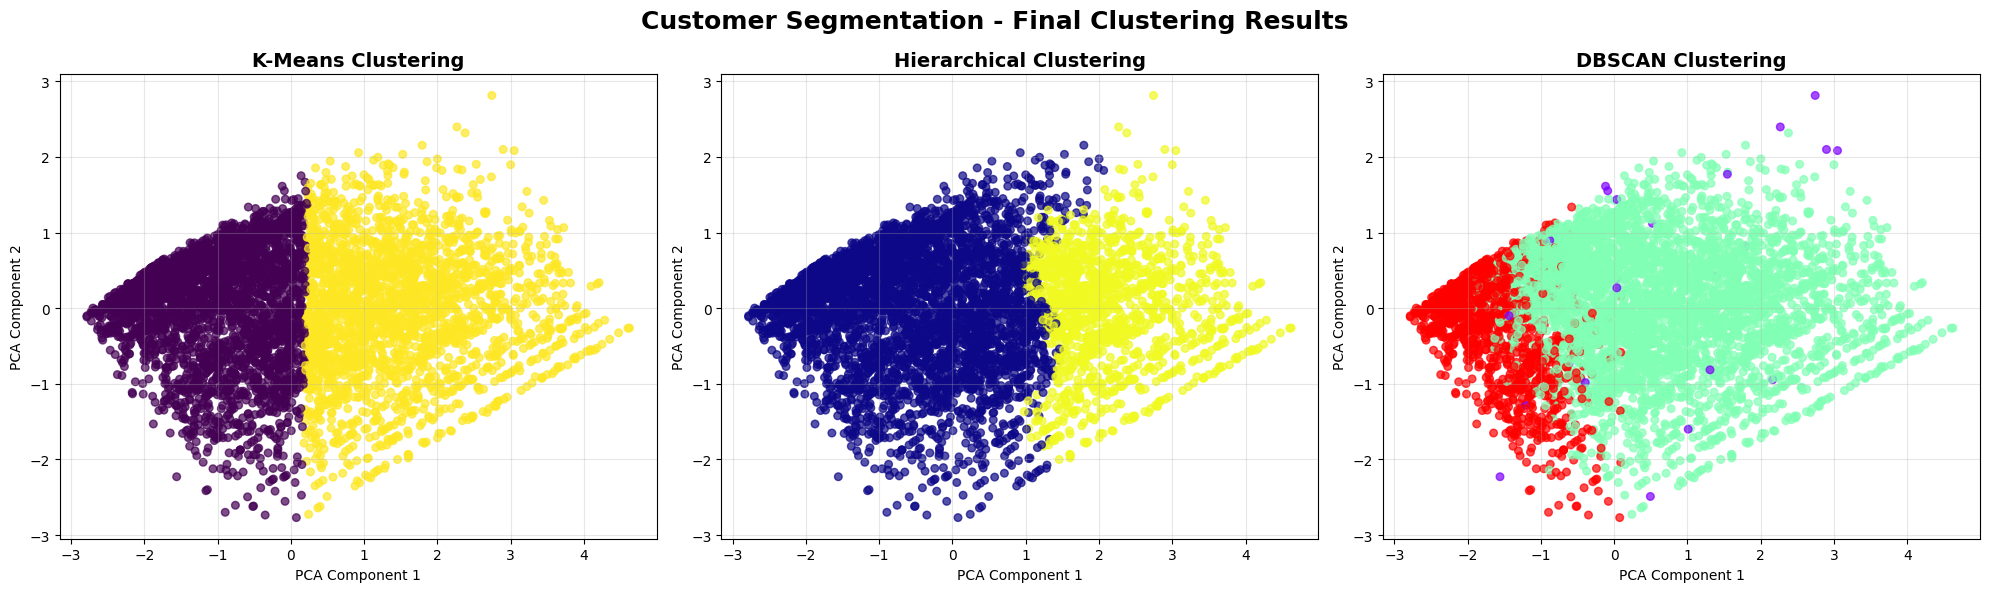


Final graphical result saved as:
final_clustering_results.png


In [2]:
# ============================================================
# FINAL GRAPHICAL REPRESENTATION OF ALL 3 CLUSTERING METHODS
# ============================================================

from sklearn.decomposition import PCA

# ------------------------------------------------------------
# PCA: Convert 3 RFM dimensions into 2 dimensions
# ------------------------------------------------------------

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

# Add PCA values to RFM dataframe
rfm["PCA1"] = X_pca[:, 0]
rfm["PCA2"] = X_pca[:, 1]

# ------------------------------------------------------------
# CREATE FINAL GRAPH
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ============================================================
# K-MEANS GRAPH
# ============================================================

scatter1 = axes[0].scatter(
    rfm["PCA1"],
    rfm["PCA2"],
    c=rfm["KMeans_Cluster"],
    cmap="viridis",
    s=30,
    alpha=0.7
)

axes[0].set_title(
    "K-Means Clustering",
    fontsize=14,
    fontweight="bold"
)

axes[0].set_xlabel("PCA Component 1")
axes[0].set_ylabel("PCA Component 2")

axes[0].grid(True, alpha=0.3)

# ============================================================
# HIERARCHICAL GRAPH
# ============================================================

scatter2 = axes[1].scatter(
    rfm["PCA1"],
    rfm["PCA2"],
    c=rfm["Hierarchical_Cluster"],
    cmap="plasma",
    s=30,
    alpha=0.7
)

axes[1].set_title(
    "Hierarchical Clustering",
    fontsize=14,
    fontweight="bold"
)

axes[1].set_xlabel("PCA Component 1")
axes[1].set_ylabel("PCA Component 2")

axes[1].grid(True, alpha=0.3)

# ============================================================
# DBSCAN GRAPH
# ============================================================

scatter3 = axes[2].scatter(
    rfm["PCA1"],
    rfm["PCA2"],
    c=rfm["DBSCAN_Cluster"],
    cmap="rainbow",
    s=30,
    alpha=0.7
)

axes[2].set_title(
    "DBSCAN Clustering",
    fontsize=14,
    fontweight="bold"
)

axes[2].set_xlabel("PCA Component 1")
axes[2].set_ylabel("PCA Component 2")

axes[2].grid(True, alpha=0.3)

# ------------------------------------------------------------
# MAIN TITLE
# ------------------------------------------------------------

plt.suptitle(
    "Customer Segmentation - Final Clustering Results",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# ============================================================
# SAVE GRAPH
# ============================================================

fig.savefig(
    "final_clustering_results.png",
    dpi=300,
    bbox_inches="tight"
)

print("\nFinal graphical result saved as:")
print("final_clustering_results.png")